In [1]:
# %pip uninstall nomad -y
# %pip install git+https://github.com/Watts-Lab/nomad.git@filtering#egg=nomad

In [2]:
import pandas as pd
import numpy as np
import boto3
import matplotlib.pyplot as plt
from shapely.geometry import Polygon
from datetime import datetime
import matplotlib.patches as patches

import nomad.filters as filters
from nomad.filters import to_projection, filter_to_polygon

### Load Data

In [3]:
s3_path = "synthetic-raw-data/agents-1-1000/sparse_trajectories.parquet/"

raw_traj = pd.read_parquet(f"s3://{s3_path}", engine="pyarrow", storage_options={"anon": False})
raw_traj['datetime'] = pd.to_datetime(raw_traj['timestamp'], unit='s')

print(raw_traj.head())

                 uid   timestamp   latitude  longitude        date  \
0  wonderful_swirles  1704112320  38.319779 -36.666237  2024-01-01   
1  wonderful_swirles  1704112740  38.319781 -36.666192  2024-01-01   
2  wonderful_swirles  1704150720  38.320875 -36.667511  2024-01-01   
3  wonderful_swirles  1704150900  38.320921 -36.667437  2024-01-01   
4  wonderful_swirles  1704151440  38.320879 -36.667510  2024-01-01   

             datetime  
0 2024-01-01 12:32:00  
1 2024-01-01 12:39:00  
2 2024-01-01 23:12:00  
3 2024-01-01 23:15:00  
4 2024-01-01 23:24:00  


### Project between coordinate systems

In [4]:
traj_cols = {
    "user_id": "uid",
    "latitude": "latitude",
    "longitude": "longitude",
    "timestamp": "timestamp",
    "datetime": "datetime",
}

traj = to_projection(traj=raw_traj,
                     from_crs="EPSG:4326",
                     to_crs="EPSG:3857",
                     traj_cols=traj_cols)

print(traj.head())

                 uid   timestamp   latitude  longitude        date  \
0  wonderful_swirles  1704112320  38.319779 -36.666237  2024-01-01   
1  wonderful_swirles  1704112740  38.319781 -36.666192  2024-01-01   
2  wonderful_swirles  1704150720  38.320875 -36.667511  2024-01-01   
3  wonderful_swirles  1704150900  38.320921 -36.667437  2024-01-01   
4  wonderful_swirles  1704151440  38.320879 -36.667510  2024-01-01   

             datetime             x             y  
0 2024-01-01 12:32:00 -4.081667e+06  4.624699e+06  
1 2024-01-01 12:39:00 -4.081662e+06  4.624699e+06  
2 2024-01-01 23:12:00 -4.081809e+06  4.624854e+06  
3 2024-01-01 23:15:00 -4.081800e+06  4.624861e+06  
4 2024-01-01 23:24:00 -4.081809e+06  4.624855e+06  


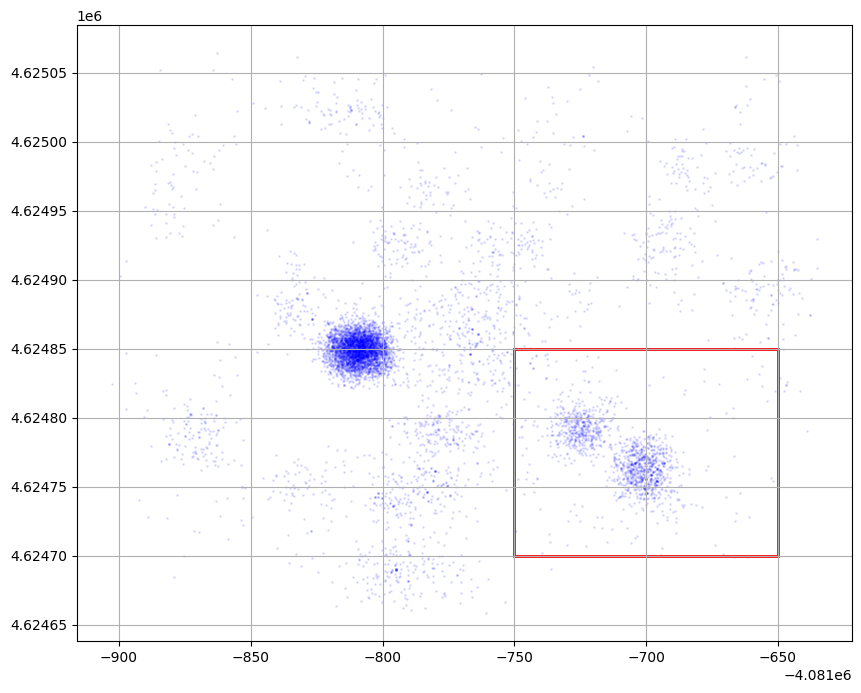

In [5]:
df = traj[traj['uid'] == "wonderful_swirles"]

plt.figure(figsize=(10, 8))
plt.scatter(df['x'], df['y'], s=1, alpha=0.1, c='blue')

polygon_coords = [
    (-4.081750e+06, 4.62470e+06), 
    (-4.081750e+06, 4.62485e+06), 
    (-4.081650e+06, 4.62485e+06), 
    (-4.081650e+06, 4.62470e+06)
]
polygon = Polygon(polygon_coords)

polygon_patch = patches.Polygon(polygon.exterior.coords, closed=True, edgecolor='red', facecolor='none', linewidth=2, label="Polygon")
plt.gca().add_patch(polygon_patch)

# Grid for better readability
plt.grid(True)

# Show the plot
plt.show()

### Filter to a specified geometry
Options:
- spatial filtering: `polygon`
- temporal filtering: `T0`, `T1`
- count filtering: `k`, `m` 

In [ ]:
polygon_coords = [
    (-4.081750e+06, 4.62470e+06), 
    (-4.081750e+06, 4.62485e+06), 
    (-4.081650e+06, 4.62485e+06), 
    (-4.081650e+06, 4.62470e+06)
]
polygon = Polygon(polygon_coords)

n0 = len(traj)

traj = filter_to_polygon(traj=traj, 
                         T0=datetime.strptime("2024-01-01 00:00:00", "%Y-%m-%d %H:%M:%S"),
                         T1=datetime.strptime("2024-01-31 23:59:00", "%Y-%m-%d %H:%M:%S"),
                         polygon=polygon,
                         k=5,
                         m=50,
                         traj_cols=traj_cols)

n1 = len(traj)
unique_users = traj['uid'].unique()
print(f"Number of pings before filtering: {n0}")
print(f"Number of pings after filtering: {n1}")
print(f"Number of unique users: {len(unique_users)}")

Number of pings before filtering: 728440
Number of pings after filtering: 319823
Number of unique users: 9


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/nomad/filters.py:249: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[datetime.date(2024, 1, 1) datetime.date(2024, 1, 1)
 datetime.date(2024, 1, 1) ... datetime.date(2024, 1, 31)
 datetime.date(2024, 1, 31) datetime.date(2024, 1, 31)]' has dtype incompatible with category, please explicitly cast to a compatible dtype first.
  traj_filtered.loc[:, 'date'] = traj_filtered[traj_cols['datetime']].dt.date  # Extract date
